In [1]:
import os
from os import listdir

from os.path import isfile, join, dirname, basename
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import matplotlib.gridspec as gridspec

In [4]:
%run analysis_utils.py

In [5]:
def process_and_sort(df):
    model_means = df.groupby('experiment')['mean'].mean().reset_index(name='mean_overall')
    # model_means = df.groupby('experiment')['mean'].median().reset_index(name='mean_overall')

    model_groups = df[['experiment', 'group']].drop_duplicates()

    sorted_models = model_means.merge(model_groups, on='experiment')
    sorted_models = sorted_models.sort_values(by=['group', 'mean_overall'], ascending=[True, False])
    sorted_model_order = sorted_models['experiment'].tolist()

    heatmap_df = df.pivot(index='experiment_name', columns='experiment', values='mean')
    heatmap_df = heatmap_df[sorted_model_order]

    return heatmap_df, sorted_models

In [6]:

def plot_composite_by_group_panels(heatmap_df, sorted_models, metric, clf='avg', save_dir='.'):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import matplotlib.gridspec as gridspec
    import numpy as np
    from os.path import join
    from matplotlib.cm import get_cmap
    from matplotlib.colors import Normalize

    sorted_models = sorted_models.round(2)
    heatmap_df = heatmap_df.round(2)

    # Calculate row-wise averages and sort
    row_avg = heatmap_df.mean(axis=1)
    heatmap_df = heatmap_df.loc[row_avg.sort_values(ascending=False).index]

    grouped = sorted_models.groupby('group')
    n_groups = len(grouped)
    palette = sns.color_palette("husl", n_groups)
    color_map = dict(zip(grouped.groups.keys(), palette))

    global_vmin = heatmap_df.min().min()
    global_vmax = heatmap_df.max().max()
    norm = Normalize(vmin=global_vmin, vmax=global_vmax)
    cmap = get_cmap('viridis')

    total_models = sum(len(group_df) for _, group_df in grouped)
    fig = plt.figure(figsize=(max(6, total_models * 0.5 + 1.5), max(6, heatmap_df.shape[0] * 0.6)))

    group_model_counts = [len(group_df) for _, group_df in grouped]

    # gs = gridspec.GridSpec(
    #     3,
    #     n_groups + 2,
    #     width_ratios=group_model_counts + [0.2, 1.0],
    #     height_ratios=[1.2, 6, 0.4],
    #     hspace=0.3,
    #     wspace=0.1
    # )

    gs = gridspec.GridSpec(
        3,
        n_groups + 2,  # +2 for row avg and colorbar
        width_ratios=group_model_counts + [1.0, 0.2],  # row avg, colorbar
        height_ratios=[1.2, 6, 0.4],
        hspace=0.3,
        wspace=0.1
    )
        
    for i, (group_name, group_df) in enumerate(grouped):
        # cbar = (i == n_groups - 1)
        # cbar_ax = fig.add_subplot(gs[1, -2]) if cbar else None

        cbar = (i == n_groups - 1)
        cbar_ax = fig.add_subplot(gs[1, -1]) if cbar else None  # now last column
        
        color = color_map[group_name]
        model_names = group_df['experiment'].tolist()
        model_avg = group_df['mean_overall'].tolist()
        group_heatmap = heatmap_df[model_names]

        # Top bar plot
        ax_top = fig.add_subplot(gs[0, i])
        bars = ax_top.bar(range(len(model_avg)), model_avg, color=color)
        ax_top.set_xticks([])
        ax_top.set_yticks([])
        # ax_top.set_title(f"{group_name}\nAvg {metric}", fontsize=6)
        ax_top.set_ylim(0.7, 1)

        # Remove all spines (bounding boxes)
        for spine in ax_top.spines.values():
            spine.set_visible(False)

        for idx, bar in enumerate(bars):
            height = bar.get_height()
            ax_top.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f"{height:.2f}", ha='center', va='bottom', fontsize=6)

        # Heatmap
        ax_heatmap = fig.add_subplot(gs[1, i])
        sns.heatmap(
            group_heatmap,
            ax=ax_heatmap,
            annot=False,
            fmt=".2f",
            cmap='viridis',
            vmin=global_vmin,
            vmax=global_vmax,
            cbar=cbar,
            cbar_ax=cbar_ax,
            xticklabels=False,
            annot_kws={"size": 6}
        )
        ax_heatmap.set_xticklabels([])
        ax_heatmap.tick_params(axis='x', bottom=False)
        ax_heatmap.set_xlabel(group_name)
        if i != 0:
            ax_heatmap.set_ylabel("")
            ax_heatmap.set_yticks([])
            ax_heatmap.set_yticklabels([])

        xticklabels = model_names
        ax_heatmap.tick_params(axis='x', rotation=90, labelsize=8)
        ax_heatmap.set_ylabel('')

        # Bottom color bar
        ax_bottom = fig.add_subplot(gs[2, i])
        for j in range(len(model_names)):
            ax_bottom.add_patch(plt.Rectangle((j, 0), 1, 1, color=color))
            
        ax_bottom.set_xlim(0, len(model_names))
        ax_bottom.set_ylim(0, 1)
        ax_bottom.axis('off')
        for j, model in enumerate(model_names):
            ax_bottom.text(j + 0.5, -0.2, model, ha='right', va='top', rotation=90, fontsize=10, rotation_mode='anchor')

     # Right-side bar plot: row average
    # ax_right_bar = fig.add_subplot(gs[1, -1])
    # avg_vals = heatmap_df.mean(axis=1)
    # y_positions = np.arange(len(avg_vals))
    
    # Right-side bar plot: row average (now second-to-last column)
    ax_right_bar = fig.add_subplot(gs[1, -2])
    avg_vals = heatmap_df.mean(axis=1)
    y_positions = np.arange(len(avg_vals))
    colors = [cmap(norm(val)) for val in avg_vals]

    ax_right_bar.barh(y_positions, avg_vals.values, color=colors)

    ax_right_bar.invert_yaxis()  # Align with heatmap rows
    ax_right_bar.set_xlim(0.4, 1.0)
    ax_right_bar.set_yticks([])
    ax_right_bar.set_xticks([])
    ax_right_bar.set_xlabel(f"Avg {metric}", fontsize=5)

    for spine in ax_right_bar.spines.values():
        spine.set_visible(False)
        

    # Use heatmap order and colormap for coloring
    colors = [cmap(norm(val)) for val in avg_vals]

    bars = ax_right_bar.barh(y_positions, avg_vals.values, color=colors)
    
    if cbar_ax is not None:
        cbar_ax.tick_params(labelsize=6)  # Control colorbar tick font size here

    # Align and remove ticks
    # ax_right_bar.invert_yaxis()  # Align top-down with heatmap
    # ax_right_bar.set_xlim(0.7, 1.0)
    # ax_right_bar.set_yticks([])
    # ax_right_bar.set_xticks([])
    # ax_right_bar.set_xlabel(f"Avg {metric}", fontsize=8)

    # Remove border/spines
    for spine in ax_right_bar.spines.values():
        spine.set_visible(False)

    # Group legend (optional)
    fig.subplots_adjust(bottom=0.25)
    legend_handles = [plt.Line2D([0], [0], color=c, lw=10) for c in color_map.values()]
    # fig.legend(legend_handles, color_map.keys(), loc='lower center', ncol=n_groups)

    output_path = join(save_dir, f'{metric}_{clf}.png')
    fig.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.close()
    print(f"Grouped panel heatmap saved to {output_path}")
    return fig

In [7]:
metrics= ['AUC', 'F1', 'AUPRC', 'Recall', 'Precision', 'Accuracy']

In [8]:
clfs = ['vote', 'mil', 'avg'] #['avg', 'mil']

In [9]:
test_df = pd.read_csv('~/scFM_eval/results/classification.metrics.csv')

In [10]:
test_df

,AUC,AUPRC,Accuracy,F1,Precision,Recall,model,exp,exp_path,strategy,classifier,metrics_path,group,model_display,exp_display
0,0.571429,0.250000,0.875000,0.466667,0.437500,0.50,cellplm_85M-20231027,brca_chemo,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,vote,randomforest,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,Other,CellPLM,Treatment Naive vs Neoadjuvant Chemo
1,0.916667,0.833333,0.750000,0.428571,0.375000,0.50,cellplm_85M-20231027,brca_chemo,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,vote,randomforest,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,Other,CellPLM,Treatment Naive vs Neoadjuvant Chemo
2,0.833333,0.750000,0.750000,0.428571,0.375000,0.50,cellplm_85M-20231027,brca_chemo,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,vote,randomforest,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,Other,CellPLM,Treatment Naive vs Neoadjuvant Chemo
3,0.583333,0.366667,0.750000,0.428571,0.375000,0.50,cellplm_85M-20231027,brca_chemo,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,vote,randomforest,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,Other,CellPLM,Treatment Naive vs Neoadjuvant Chemo
4,0.000000,0.142857,0.857143,0.461538,0.428571,0.50,cellplm_85M-20231027,brca_chemo,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,vote,randomforest,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,Other,CellPLM,Treatment Naive vs Neoadjuvant Chemo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1797,1.000000,1.000000,0.750000,0.733333,0.833333,0.75,state_se600m_epoch16,melanoma_response,/mnt/data/__output_v7/exp/state/se600m_epoch16...,avg,randomforest,/mnt/data/__output_v7/exp/state/se600m_epoch16...,Other,STATE,IO Response
1798,1.000000,1.000000,1.000000,1.000000,1.000000,1.00,state_se600m_epoch16,melanoma_response,/mnt/data/__output_v7/exp/state/se600m_epoch16...,avg,randomforest,/mnt/data/__output_v7/exp/state/se600m_epoch16...,Other,STATE,IO Response
1799,1.000000,1.000000,0.750000,0.733333,0.833333,0.75,state_se600m_epoch16,melanoma_response,/mnt/data/__output_v7/exp/state/se600m_epoch16...,avg,randomforest,/mnt/data/__output_v7/exp/state/se600m_epoch16...,Other,STATE,IO Response
1800,0.500000,0.750000,0.750000,0.733333,0.833333,0.75,state_se600m_epoch16,melanoma_response,/mnt/data/__output_v7/exp/state/se600m_epoch16...,avg,randomforest,/mnt/data/__output_v7/exp/state/se600m_epoch16...,Other,STATE,IO Response


In [11]:
test_df.model.value_counts()

model
cellplm_85M-20231027                 102
geneformer_V1-10M-i2048              102
geneformer_V2-104M-i4096             102
geneformer_V2-104M_CLcancer-i4096    102
geneformer_V2-316M-i4096             102
hvg_seurat_4096                      102
nicheformer_nicheformer              102
pca_n100                             102
pca_n20                              102
pca_n50                              102
scconcept_corpus30m                  102
scfoundation                         102
scgpt_cancer-i2048                   102
scgpt_human-i2048                    102
scimilarity_v1.1                     102
scvi                                 102
state_se600m_epoch16                 102
geneformer_V1-10M-i2048_finetune      34
geneformer_V2-104M-i4096_finetune     34
Name: count, dtype: int64

In [12]:
exclude = (
    test_df.model_display.str.contains("continue")
    | test_df.model_display.str.contains("Full")
    | test_df.model_display.isin(["PCA [100]", "PCA [50]"])
)
test_df = test_df.loc[~exclude].copy()

In [13]:
test_df.model_display.value_counts()

model_display
CellPLM             102
GF-V1               102
GF-V2               102
GF-V2 [cancer]      102
GF-V2-Deep          102
HVG                 102
Nicheformer         102
PCA [20]            102
scConcept           102
scFoundation        102
scGPT [cancer]      102
scGPT               102
SCimiarity          102
scVI                102
STATE               102
GF-V1 [finetune]     34
GF-V2 [finetune]     34
Name: count, dtype: int64

In [14]:
'experiment_name', 'experiment', 'group', 'mean'

('experiment_name', 'experiment', 'group', 'mean')

In [15]:
auprc_df = test_df[['AUPRC', 'model_display', 'exp_display', 'group','strategy']]

In [16]:
auprc_df = test_df[['AUPRC', 'model_display', 'exp_display', 'group','strategy']]
auprc_df_avg = auprc_df[auprc_df['strategy'] == 'avg']
auprc_df_avg
dd = auprc_df_avg.groupby(['exp_display', 'group', 'model_display', 'strategy']).mean().reset_index()
dd['mean'] = dd['AUPRC']
dd['experiment_name'] = dd['exp_display'] 
dd['experiment'] = dd['model_display']
heatmap_df_grouped, sorted_models = process_and_sort(dd)
heatmap_df_grouped
# heatmap_df_grouped  = heatmap_df_grouped.drop('luad_cancer_stage', axis=0)

experiment,HVG,scVI,PCA [20],GF-V2 [cancer],GF-V2-Deep,GF-V2,GF-V1,SCimiarity,STATE,scFoundation,scConcept,Nicheformer,CellPLM,scGPT [cancer],scGPT
experiment_name,,,,,,,,,,,,,,,
ER+ vs TNBC,0.983333,1.000000,0.983333,0.956667,0.878889,0.940000,0.878889,0.956667,0.911111,1.000000,0.867778,0.951111,0.934444,0.956667,0.851111
IO Response,0.950000,0.916667,0.800000,0.933333,0.866667,0.933333,0.900000,0.966667,0.950000,0.866667,0.916667,0.916667,0.866667,0.916667,0.816667
MMRd vs MMRp,0.937238,0.912626,0.807341,0.903365,0.888825,0.828238,0.894952,0.829921,0.893905,0.823999,0.877810,0.863206,0.858642,0.676203,0.627909
T-cell exhaustion,0.830000,0.833333,0.683333,0.673333,0.683333,0.633333,0.616667,0.806667,0.646667,0.796667,0.663333,0.623333,0.790000,0.873333,0.600000
Treatment Naive vs Anti PD1,1.000000,0.995238,0.981236,0.986905,1.000000,0.975000,0.907904,0.952744,1.000000,1.000000,0.848730,0.960714,0.771801,0.966198,0.895833
Treatment Naive vs Neoadjuvant Chemo,0.633333,0.531667,0.398333,0.706667,0.706667,0.673333,0.656667,0.660000,0.683333,0.530000,0.783333,0.616667,0.416667,0.661905,0.625238
Treatment Naive vs TKI treated,1.000000,0.875000,0.750000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


/tmp/ipykernel_2275/114508973.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('viridis')


Grouped panel heatmap saved to AUPRC_avg.png


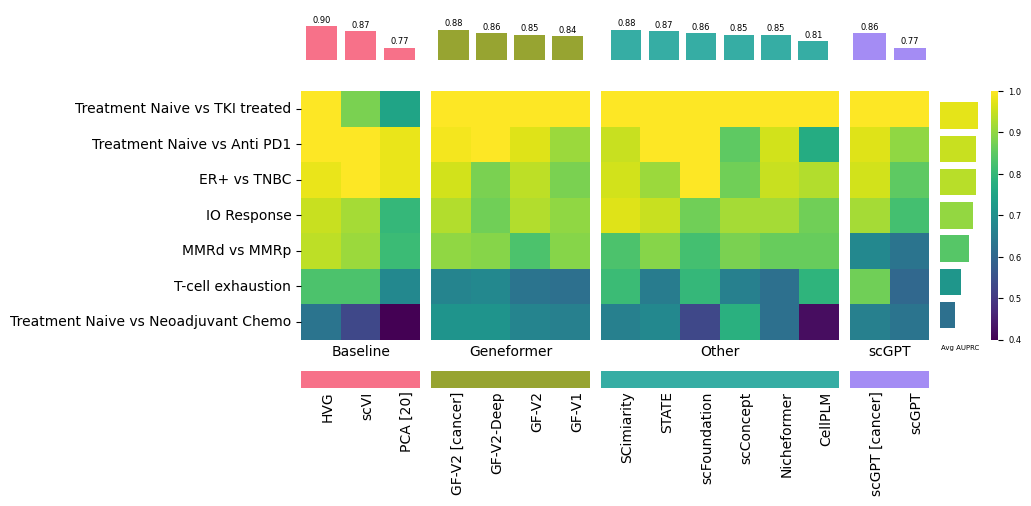

In [17]:
m = 'AUPRC'
clf = 'avg'
plot_composite_by_group_panels(heatmap_df_grouped, sorted_models, m, clf, save_dir='')

/tmp/ipykernel_2275/114508973.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('viridis')


Grouped panel heatmap saved to AUPRC_avg.png


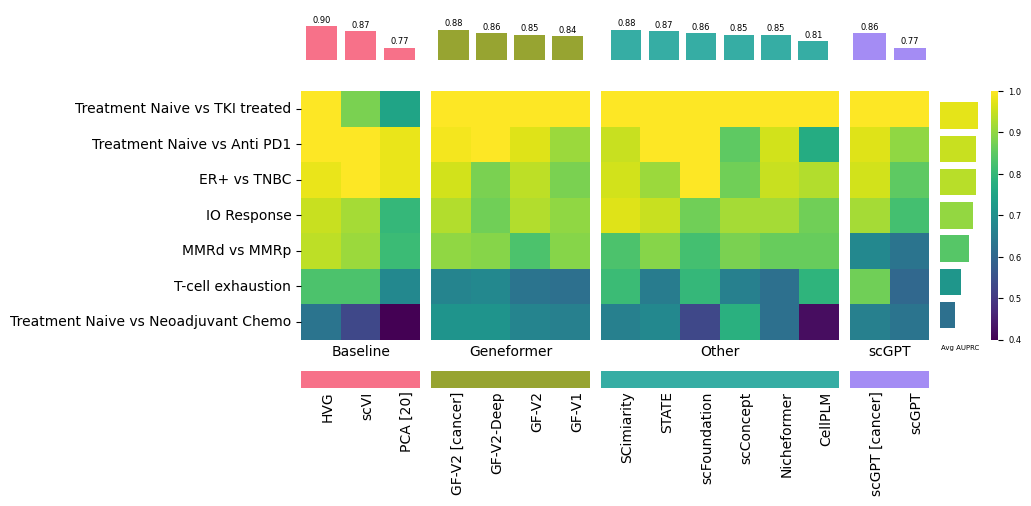

In [18]:
m = 'AUPRC'
clf = 'avg'
plot_composite_by_group_panels(heatmap_df_grouped, sorted_models, m, clf, save_dir='')

In [19]:
auprc_df = test_df[['AUPRC', 'model_display', 'exp_display', 'group','strategy']]
auprc_df_avg = auprc_df[auprc_df['strategy'] == 'MIL']
auprc_df_avg
dd = auprc_df_avg.groupby(['exp_display', 'group', 'model_display', 'strategy']).mean().reset_index()
dd['mean'] = dd['AUPRC']
dd['experiment_name'] = dd['exp_display'] 
dd['experiment'] = dd['model_display']
heatmap_df_grouped, sorted_models = process_and_sort(dd)
heatmap_df_grouped
# heatmap_df_grouped  = heatmap_df_grouped.drop('luad_cancer_stage', axis=0)

experiment,scVI,PCA [20],HVG,GF-V2 [cancer],GF-V2,GF-V2 [finetune],GF-V2-Deep,GF-V1,GF-V1 [finetune],SCimiarity,STATE,scConcept,scFoundation,Nicheformer,CellPLM,scGPT [cancer],scGPT
experiment_name,,,,,,,,,,,,,,,,,
ER+ vs TNBC,1.000000,1.000000,1.000000,1.000000,1.000000,0.973333,1.000000,0.983333,0.867778,1.000000,1.000000,0.983333,1.000000,0.983333,1.000000,0.966667,0.983333
IO Response,0.900000,0.816667,0.866667,0.933333,0.950000,0.900000,0.933333,0.833333,0.933333,0.966667,0.866667,0.950000,0.950000,0.933333,1.000000,0.916667,0.883333
MMRd vs MMRp,0.869238,0.850737,0.887198,0.930889,0.828436,0.932571,0.918746,0.802563,0.871801,0.819706,0.935293,0.815110,0.825007,0.758912,0.795316,0.572276,0.592944
T-cell exhaustion,0.866667,0.840000,0.900000,0.883333,0.833333,0.883333,0.696667,0.833333,0.780000,0.790000,0.900000,0.766667,0.840000,0.806667,0.866667,0.640000,0.723333
Treatment Naive vs Anti PD1,1.000000,1.000000,1.000000,0.984127,1.000000,0.841070,1.000000,0.907394,0.817256,0.983016,1.000000,0.934371,1.000000,1.000000,0.872963,0.844246,0.656944
Treatment Naive vs Neoadjuvant Chemo,0.673333,0.728571,0.491667,0.601905,0.673333,0.700000,0.500000,0.603333,0.551905,1.000000,0.716667,0.816667,0.506667,0.580000,0.448333,0.560714,0.568571
Treatment Naive vs TKI treated,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


/tmp/ipykernel_2275/114508973.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('viridis')


Grouped panel heatmap saved to AUPRC_mil.png


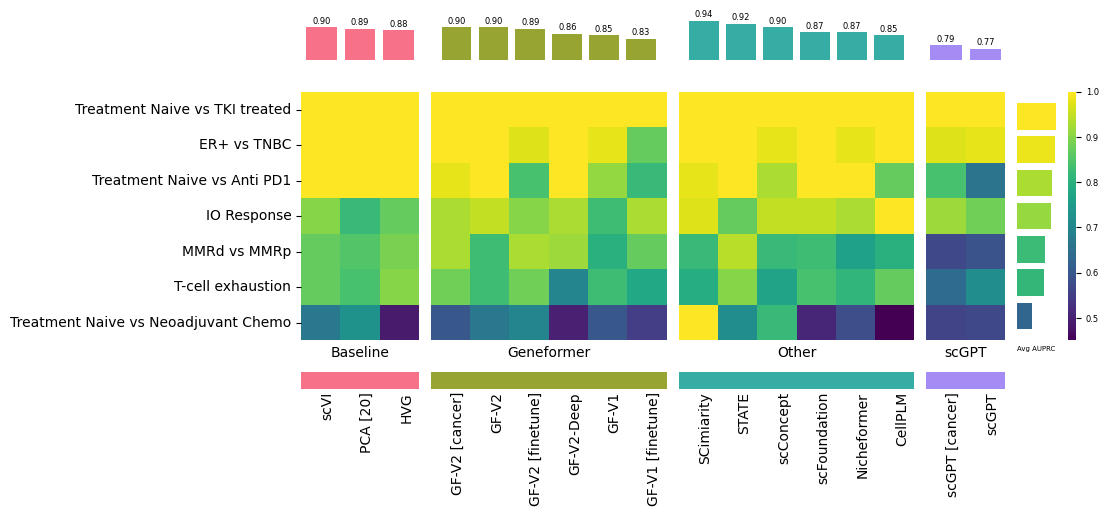

In [20]:
m = 'AUPRC'
clf = 'mil'
plot_composite_by_group_panels(heatmap_df_grouped, sorted_models, m, clf, save_dir='')

In [21]:
auprc_df = test_df[['AUPRC', 'model_display', 'exp_display', 'group','strategy']]
auprc_df_avg = auprc_df[auprc_df['strategy'] == 'vote']
auprc_df_avg
dd = auprc_df_avg.groupby(['exp_display', 'group', 'model_display', 'strategy']).mean().reset_index()
dd['mean'] = dd['AUPRC']
dd['experiment_name'] = dd['exp_display'] 
dd['experiment'] = dd['model_display']
heatmap_df_grouped, sorted_models = process_and_sort(dd)
heatmap_df_grouped
# heatmap_df_grouped  = heatmap_df_grouped.drop('luad_cancer_stage', axis=0)

experiment,scVI,HVG,PCA [20],GF-V2 [cancer],GF-V2-Deep,GF-V2,GF-V1,STATE,SCimiarity,scFoundation,Nicheformer,scConcept,CellPLM,scGPT,scGPT [cancer]
experiment_name,,,,,,,,,,,,,,,
ER+ vs TNBC,1.000000,1.000000,1.000000,1.000000,0.973333,0.973333,0.973333,1.000000,1.000000,1.000000,0.973333,0.956667,0.940000,0.956667,0.983333
IO Response,0.950000,0.916667,0.950000,0.966667,0.950000,0.916667,0.916667,0.950000,0.916667,0.916667,0.900000,0.950000,0.900000,0.950000,0.950000
MMRd vs MMRp,0.925722,0.915667,0.906778,0.896365,0.904222,0.914778,0.819254,0.922556,0.870444,0.874626,0.786595,0.917087,0.830444,0.596554,0.596554
T-cell exhaustion,0.850000,0.783333,0.696667,0.773333,0.673333,0.706667,0.773333,0.806667,0.790000,0.723333,0.763333,0.673333,0.806667,0.763333,0.800000
Treatment Naive vs Anti PD1,1.000000,1.000000,0.995238,0.995238,0.995238,0.990476,0.951005,0.995238,0.983333,1.000000,0.973810,0.898784,0.854650,0.910801,0.974531
Treatment Naive vs Neoadjuvant Chemo,0.631667,0.548333,0.438333,0.386667,0.490000,0.478571,0.496667,0.505000,0.523333,0.401905,0.506667,0.483333,0.468571,0.613333,0.458571
Treatment Naive vs TKI treated,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


/tmp/ipykernel_2275/114508973.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('viridis')


Grouped panel heatmap saved to AUPRC_vote.png


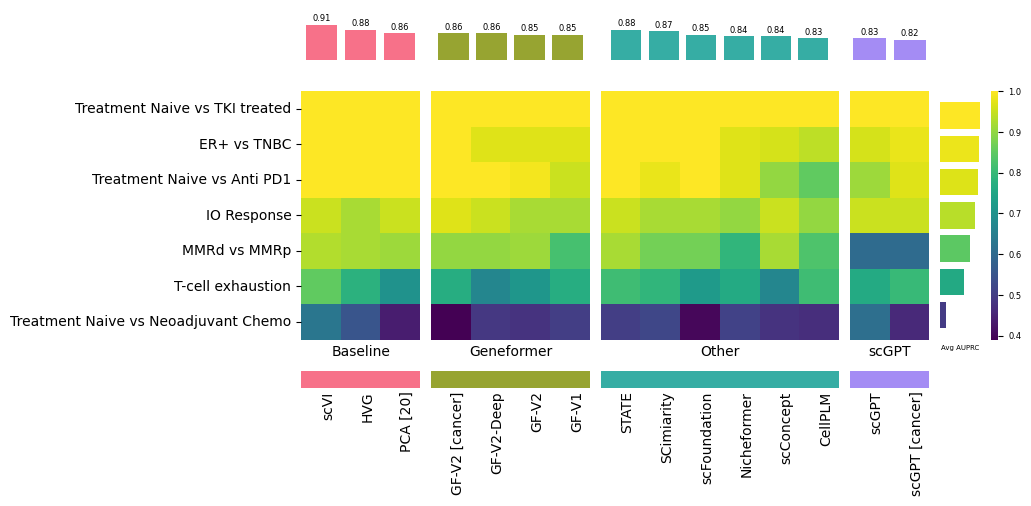

In [22]:
m = 'AUPRC'
clf = 'vote'
plot_composite_by_group_panels(heatmap_df_grouped, sorted_models, m, clf, save_dir='')

In [23]:
clfs

['vote', 'mil', 'avg']

In [24]:
metrics

['AUC', 'F1', 'AUPRC', 'Recall', 'Precision', 'Accuracy']

In [25]:
test_df.strategy.unique()

array(['vote', 'MIL', 'avg'], dtype=object)

In [26]:
metrics

['AUC', 'F1', 'AUPRC', 'Recall', 'Precision', 'Accuracy']

In [27]:
metrics

['AUC', 'F1', 'AUPRC', 'Recall', 'Precision', 'Accuracy']

In [28]:
strategy_list= test_df.strategy.unique()

In [29]:
for clf in strategy_list:
    print(clf)
    for metric in metrics:
        print(metric)
        # heatmap_df = collect_auprc_scores(metric=m,clf=clf, base_dir='./metrics')

        heatmap_df = test_df[[metric, 'model_display', 'exp_display', 'group','strategy']]
        heatmap_df = heatmap_df[heatmap_df['strategy'] == clf]

        dd = heatmap_df.groupby(['exp_display', 'group', 'model_display', 'strategy']).mean().reset_index()
        # print(dd.head)
        dd['mean'] = dd[metric]
        dd['experiment_name'] = dd['exp_display'] 
        dd['experiment'] = dd['model_display']
        idx = dd.model_display.str.contains('continue')
        dd= dd[~idx]

        idx = dd.model_display.str.contains('finetune')
        dd= dd[~idx]
        
        
        heatmap_df_grouped, sorted_models = process_and_sort(dd)
        # print(heatmap_df_grouped)

        # idx = heatmap_df.experiment.str.contains('freez')
        # heatmap_df= heatmap_df[~idx]
        
        # idx = heatmap_df.experiment.str.endswith('k')
        # heatmap_df= heatmap_df[~idx]
        
        # idx = heatmap_df.experiment.str.endswith('batch')
        # heatmap_df= heatmap_df[~idx]
    
        # idx = heatmap_df.experiment.str.endswith('_')
        # heatmap_df= heatmap_df[~idx]
        
        # idx = heatmap_df.experiment.str.endswith('all')
        # heatmap_df= heatmap_df[~idx]
        
        # heatmap_df.group = heatmap_df.group.map(group_map)
        # heatmap_df.experiment = heatmap_df.experiment.map(lambda x: model_name_map.get(x, x))
        # heatmap_df.experiment_name = heatmap_df.experiment_name.map(experiment_name_map)
        # heatmap_df['experiment_name'] = heatmap_df.experiment
        # heatmap_df_grouped, sorted_models = process_and_sort(heatmap_df)
        plot_composite_by_group_panels(heatmap_df_grouped, sorted_models, metric, clf, save_dir='./plots')
        

vote
AUC


/tmp/ipykernel_2275/114508973.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('viridis')


Grouped panel heatmap saved to ./plots/AUC_vote.png
F1


/tmp/ipykernel_2275/114508973.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('viridis')


Grouped panel heatmap saved to ./plots/F1_vote.png
AUPRC


...

Grouped panel heatmap saved to ./plots/Recall_avg.png
Precision


/tmp/ipykernel_2275/114508973.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('viridis')


Grouped panel heatmap saved to ./plots/Precision_avg.png
Accuracy


/tmp/ipykernel_2275/114508973.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('viridis')


Grouped panel heatmap saved to ./plots/Accuracy_avg.png
